In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
df = pd.read_csv('/content/drive/MyDrive/datasets/mymoviedb.csv', sep=',', engine='python')
display(df.head())

,Release_Date,Title,Overview,Popularity,Vote_Count,Vote_Average,Original_Language,Genre,Poster_Url
0,2021-12-15,Spider-Man: No Way Home,Peter Parker is unmasked and no longer able to...,5083.954,8940,8.3,en,"Action, Adventure, Science Fiction",https://image.tmdb.org/t/p/original/1g0dhYtq4i...
1,2022-03-01,The Batman,"In his second year of fighting crime, Batman u...",3827.658,1151,8.1,en,"Crime, Mystery, Thriller",https://image.tmdb.org/t/p/original/74xTEgt7R3...
2,2022-02-25,No Exit,Stranded at a rest stop in the mountains durin...,2618.087,122,6.3,en,Thriller,https://image.tmdb.org/t/p/original/vDHsLnOWKl...
3,2021-11-24,Encanto,"The tale of an extraordinary family, the Madri...",2402.201,5076,7.7,en,"Animation, Comedy, Family, Fantasy",https://image.tmdb.org/t/p/original/4j0PNHkMr5...
4,2021-12-22,The King's Man,As a collection of history's worst tyrants and...,1895.511,1793,7.0,en,"Action, Adventure, Thriller, War",https://image.tmdb.org/t/p/original/aq4Pwv5Xeu...


# i already performed univariate on same dataset now i will explore bivariate/multivariate analysis on the same movies data

In [ ]:
df['Release_Date'] = pd.to_datetime(df['Release_Date'], errors='coerce', format='mixed')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9837 entries, 0 to 9836
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Release_Date       9827 non-null   datetime64[ns]
 1   Title              9828 non-null   object        
 2   Overview           9828 non-null   object        
 3   Popularity         9827 non-null   float64       
 4   Vote_Count         9827 non-null   object        
 5   Vote_Average       9827 non-null   object        
 6   Original_Language  9827 non-null   object        
 7   Genre              9826 non-null   object        
 8   Poster_Url         9826 non-null   object        
dtypes: datetime64[ns](1), float64(1), object(7)
memory usage: 691.8+ KB


In [ ]:
# Convert 'Vote_Count' and 'Vote_Average' to numeric, coercing errors
df['Vote_Count'] = pd.to_numeric(df['Vote_Count'], errors='coerce')
df['Vote_Average'] = pd.to_numeric(df['Vote_Average'], errors='coerce')

# Fill null values for numerical columns with their median
numerical_cols = ['Popularity', 'Vote_Count', 'Vote_Average']
for col in numerical_cols:
    if col in df.columns:
        df[col] = df[col].fillna(df[col].median())

# Fill null values for object (string) columns with 'Unknown'
object_cols = ['Title', 'Overview', 'Original_Language', 'Genre', 'Poster_Url']
for col in object_cols:
    if col in df.columns:
        df[col] = df[col].fillna('Unknown')

# Fill null values for 'Release_Date' (datetime) with the mode
# The mode is appropriate for categorical or date/time features where a single most frequent value makes sense.
if 'Release_Date' in df.columns:
    df['Release_Date'] = df['Release_Date'].fillna(df['Release_Date'].mode()[0])

# Display the count of null values after filling to verify
display(df.isnull().sum())

,0
Release_Date,0
Title,0
Overview,0
Popularity,0
Vote_Count,0
Vote_Average,0
Original_Language,0
Genre,0
Poster_Url,0


## Bivariate and Multivariate Analysis

### Numerical-Numerical Relationships

First, let's explore the relationships between the numerical columns: `Popularity`, `Vote_Count`, and `Vote_Average`.

Correlation Matrix:


,Popularity,Vote_Count,Vote_Average
Popularity,1.000000,0.137475,0.053821
Vote_Count,0.137475,1.000000,0.253572
Vote_Average,0.053821,0.253572,1.000000


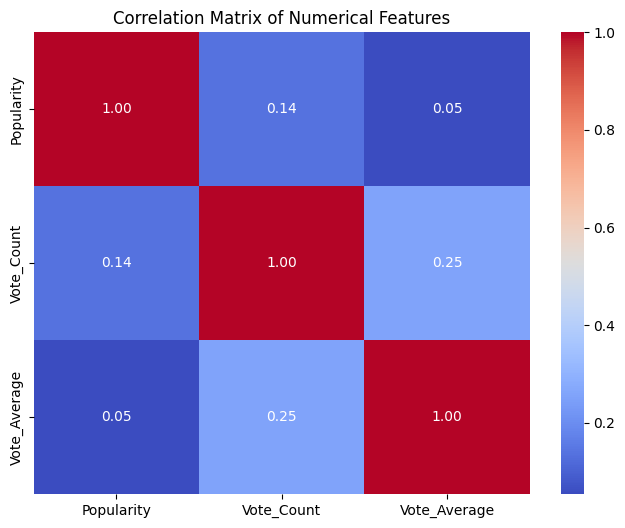

In [ ]:
# Select numerical columns for correlation analysis
numerical_df = df[['Popularity', 'Vote_Count', 'Vote_Average']]

# Calculate the correlation matrix
correlation_matrix = numerical_df.corr()

print("Correlation Matrix:")
display(correlation_matrix)

# Visualize the correlation matrix using a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Numerical Features')
plt.show()

From the heatmap, we can observe the strength and direction of the linear relationships between pairs of numerical variables. Now, let's look at scatter plots to visualize these relationships individually.

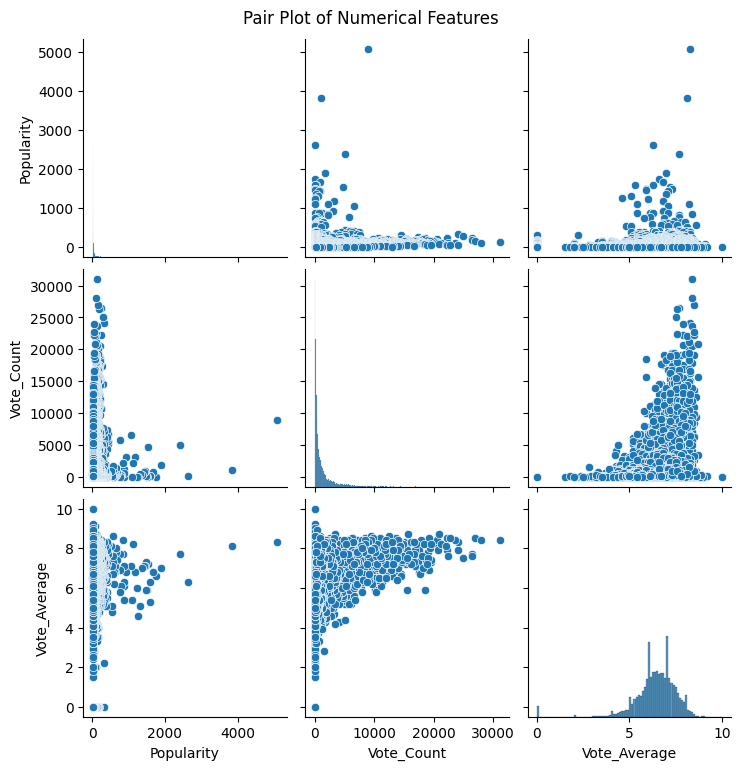

In [ ]:
# Pair plot to visualize relationships between numerical variables
sns.pairplot(numerical_df)
plt.suptitle('Pair Plot of Numerical Features', y=1.02)
plt.show()

### Numerical-Categorical Relationships

Next, let's explore how numerical features (`Popularity`, `Vote_Count`, `Vote_Average`) are distributed across categorical features such as `Original_Language` and `Genre`.

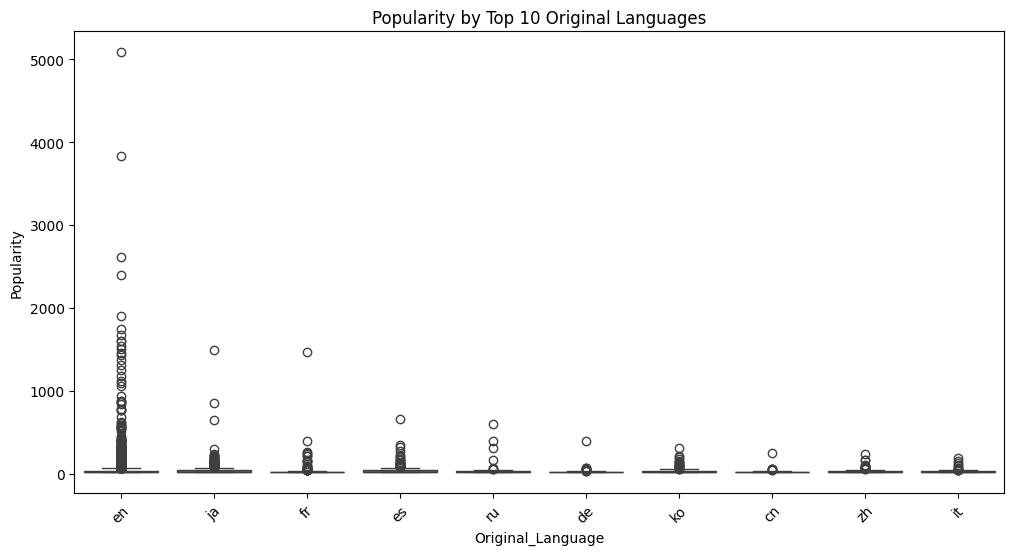

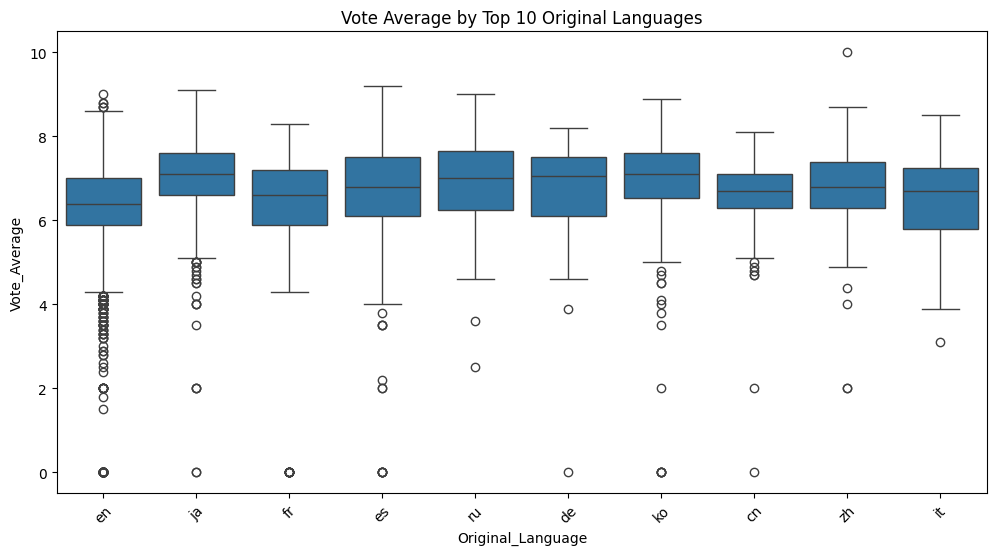

In [ ]:
# Analyze Popularity by Original Language (top 10 languages)
top_languages = df['Original_Language'].value_counts().head(10).index
plt.figure(figsize=(12, 6))
sns.boxplot(data=df[df['Original_Language'].isin(top_languages)], x='Original_Language', y='Popularity')
plt.title('Popularity by Top 10 Original Languages')
plt.xticks(rotation=45)
plt.show()

# Analyze Vote Average by Original Language (top 10 languages)
plt.figure(figsize=(12, 6))
sns.boxplot(data=df[df['Original_Language'].isin(top_languages)], x='Original_Language', y='Vote_Average')
plt.title('Vote Average by Top 10 Original Languages')
plt.xticks(rotation=45)
plt.show()

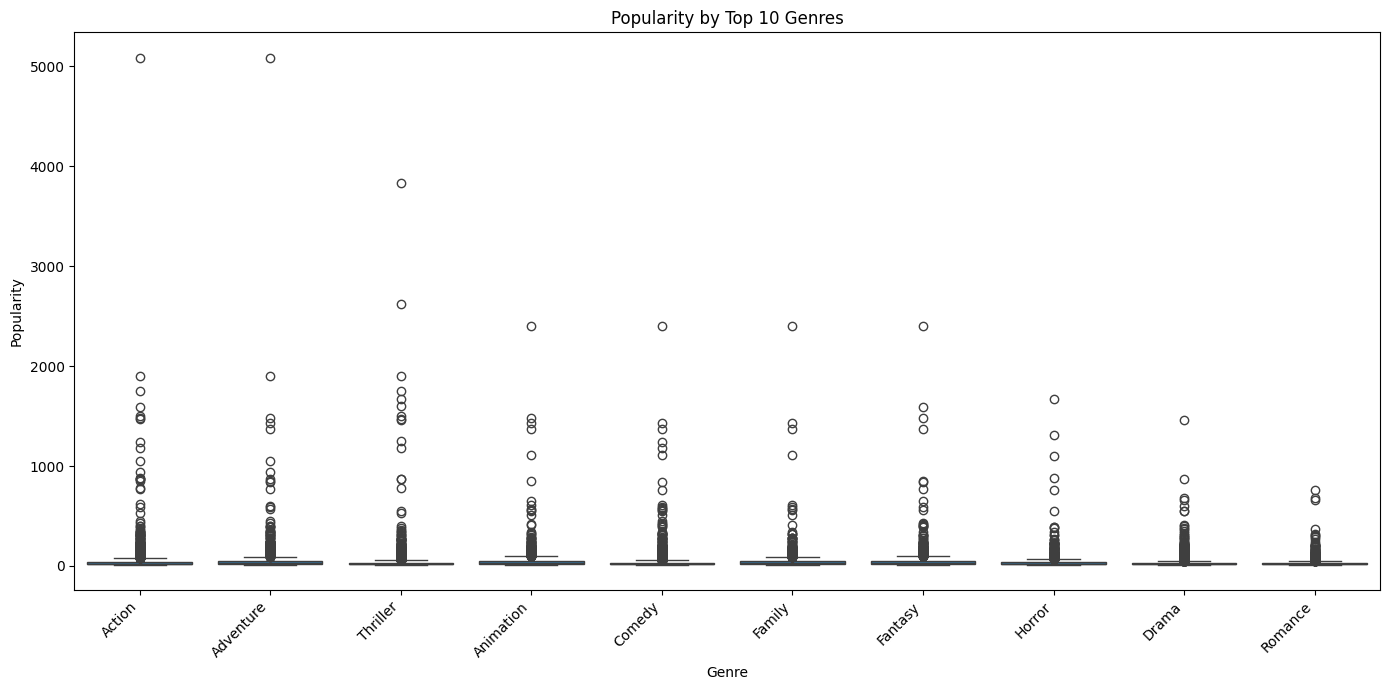

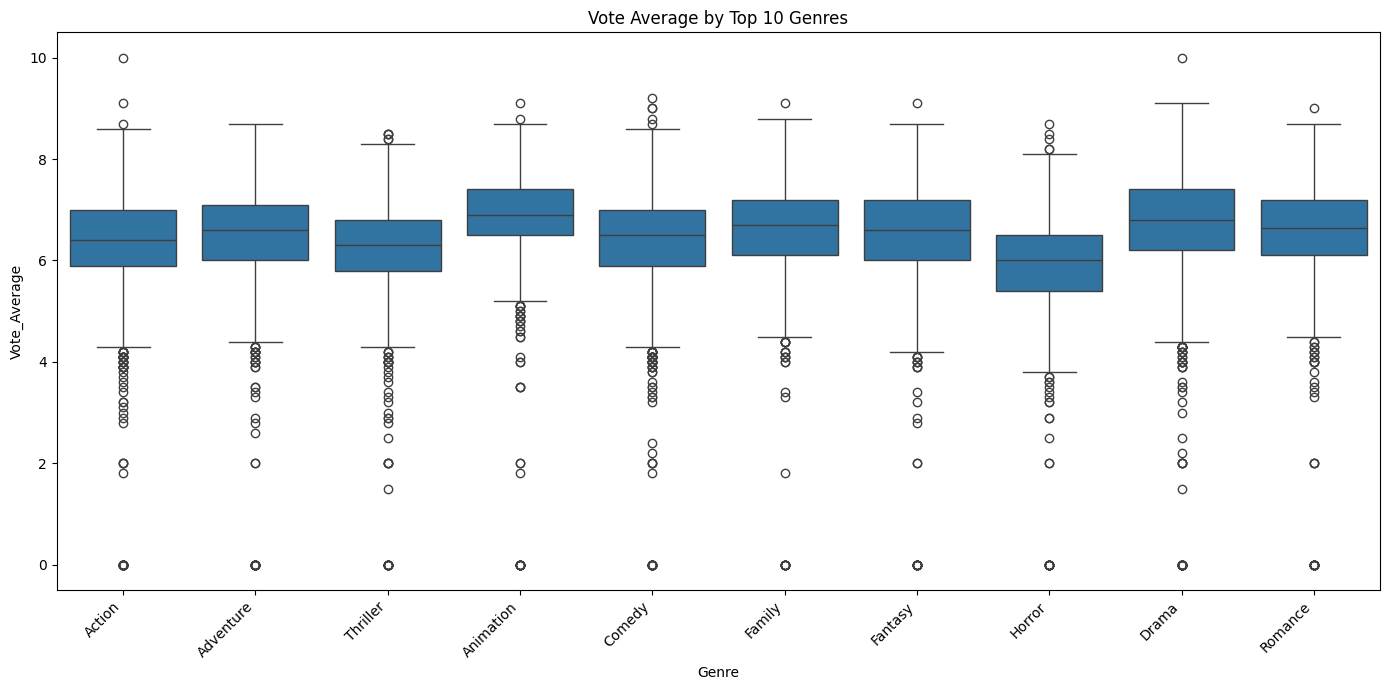

In [ ]:
# Since 'Genre' can contain multiple genres, let's explode it first to analyze individual genres.
df_genres = df.assign(Genre=df['Genre'].str.split(', ')).explode('Genre')

# Analyze Popularity by Genre (top 10 genres)
top_genres = df_genres['Genre'].value_counts().head(10).index
plt.figure(figsize=(14, 7))
sns.boxplot(data=df_genres[df_genres['Genre'].isin(top_genres)], x='Genre', y='Popularity')
plt.title('Popularity by Top 10 Genres')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Analyze Vote Average by Genre (top 10 genres)
plt.figure(figsize=(14, 7))
sns.boxplot(data=df_genres[df_genres['Genre'].isin(top_genres)], x='Genre', y='Vote_Average')
plt.title('Vote Average by Top 10 Genres')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Categorical-Categorical Relationships

Finally, let's examine the relationships between categorical features. We can use count plots or cross-tabulations to understand the distributions and co-occurrences of categories.

Primary_Genre,Action,Adventure,Animation,Comedy,Crime,Drama,Family,Horror,Romance,Thriller
Original_Language,,,,,,,,,,
cn,59,5,0,11,7,18,0,1,1,3
de,4,5,6,14,0,31,1,5,2,6
en,1168,494,482,1194,324,1262,304,760,201,425
es,8,3,17,94,10,102,7,29,11,31
fr,25,18,15,64,11,99,11,7,11,5
it,9,7,0,24,6,40,2,10,8,3
ja,158,27,256,22,7,55,20,27,23,8
ko,38,2,1,11,11,44,0,5,27,8
ru,4,5,5,7,0,23,3,4,4,3


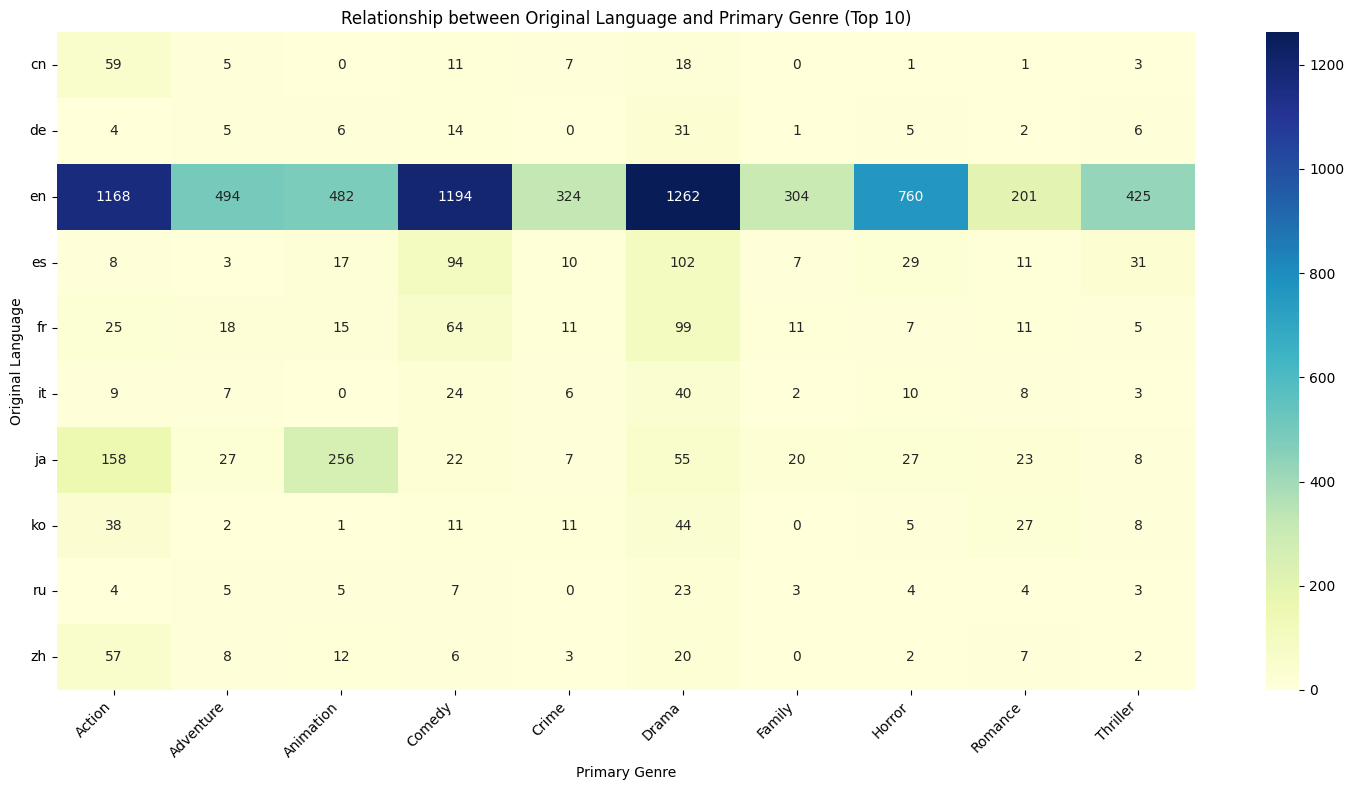

In [ ]:
# Analyze the relationship between Original_Language and Genre
# For simplicity, let's consider the primary genre if multiple are listed, and top N genres/languages.

# Prepare data for categorical-categorical analysis
# Take the first genre if there are multiple for easier analysis
df_single_genre = df.copy()
df_single_genre['Primary_Genre'] = df_single_genre['Genre'].apply(lambda x: x.split(', ')[0] if isinstance(x, str) else 'Unknown')

# Select top 10 languages and top 10 primary genres for cleaner visualization
top_languages = df_single_genre['Original_Language'].value_counts().head(10).index
top_genres = df_single_genre['Primary_Genre'].value_counts().head(10).index

df_filtered = df_single_genre[
    df_single_genre['Original_Language'].isin(top_languages) &
    df_single_genre['Primary_Genre'].isin(top_genres)
]

# Create a cross-tabulation (contingency table)
crosstab_lang_genre = pd.crosstab(df_filtered['Original_Language'], df_filtered['Primary_Genre'])
display(crosstab_lang_genre)

# Visualize the relationship using a stacked bar chart or heatmap
plt.figure(figsize=(15, 8))
sns.heatmap(crosstab_lang_genre, annot=True, fmt='d', cmap='YlGnBu')
plt.title('Relationship between Original Language and Primary Genre (Top 10)')
plt.ylabel('Original Language')
plt.xlabel('Primary Genre')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## Pandas Profiling Report

To get a comprehensive statistical overview of the dataset, including distributions, missing values, and correlations, let's generate a Pandas Profiling Report. This report will be saved as an HTML file.

In [ ]:
# Install ydata-profiling if not already installed
!pip install ydata-profiling

# Import ProfileReport
from ydata_profiling import ProfileReport

# Generate the profile report
profile = ProfileReport(df, title="Pandas Profiling Report for Movie Dataset")

# Save the report to an HTML file
profile.to_file("output.html")

print("Pandas Profiling Report saved as output.html")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.8/400.8 kB 11.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 22.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 56.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 679.7/679.7 kB 43.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.4/105.4 kB 9.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 5.8 MB/s eta 0:00:00


/tmp/ipykernel_1375/487224184.py:5: DeprecationWarning: 
    `import ydata_profiling` is deprecated and will not receive more updates. 
    Please install fg-data-profiling via `pip install fg-data-profiling` and use `import data_profiling` instead.
    
  from ydata_profiling import ProfileReport


Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 9/9 [00:01<00:00,  6.52it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

Pandas Profiling Report saved as output.html
